# Previsão de Inadimplência em Cartão de Crédito — Projeto ML
## Notebook 05: Modelo Avançado — Random Forest

**Dataset:** UCI Credit Card Default (Taiwan, 2005)  

---

## 1. Introdução

### 1.1 Motivação para um Modelo Avançado

Os modelos anteriores estabeleceram um panorama claro:
- **Perceptron**: baseline linear, underfitting, incapaz de capturar padrões não-lineares
- **Árvore Padrão**: overfitting severo, alta variância, baixa generalização
- **Árvore Otimizada**: regularização corrigiu o overfitting, mas uma única árvore ainda tem **alta variância**

### 1.2 Random Forest — Ensemble de Árvores

O **Random Forest** resolve o problema de variância da árvore individual através de dois mecanismos:

**1. Bootstrap Aggregating (Bagging):**
- Treina N árvores em subconjuntos aleatórios do dataset (com reposição)
- Cada árvore vê dados ligeiramente diferentes → aprende perspectivas diferentes
- A predição final é a votação majoritária das N árvores

**2. Feature Randomness (Seleção Aleatória de Features):**
- Em cada nó de cada árvore, apenas um subconjunto aleatório de features é considerado
- Isso garante diversidade entre as árvores (se todas usassem as mesmas features, seriam muito similares)

**Por que a média reduz a variância?**
- Matematicamente: $\text{Var}\left(\frac{1}{N}\sum X_i\right) = \frac{\sigma^2}{N}$ (para variáveis independentes)
- Na prática: as árvores são correlacionadas, mas a diversidade introduzida pelo bagging e feature randomness reduz significativamente a variância total

### 1.3 Vantagens sobre Árvore Única

| Aspecto | Árvore Única | Random Forest |
|---|---|---|
| **Variância** | Alta | Baixa (N árvores) |
| **Overfitting** | Propenso | Resistente |
| **Interpretabilidade** | Alta (regras explícitas) | Média (importância de features) |
| **Estabilidade** | Baixa | Alta |
| **Performance** | Moderada | Geralmente superior |

---

## 2. Setup e Carregamento de Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc
)
import pickle
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from utils import evaluate_model, compare_models, create_results_dataframe, analyze_feature_importance

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [2]:
# Carregar dataset
df = pd.read_csv('../data/credit_card_cleaned.csv')
X = df.drop(['ID', 'default'], axis=1)
y = df['default']
feature_names = X.columns.tolist()

# Mesmo split dos notebooks anteriores
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Carregar modelos anteriores
with open('../models/perceptron_baseline.pkl', 'rb') as f:
    perceptron = pickle.load(f)
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../models/decision_tree_default.pkl', 'rb') as f:
    dt_default = pickle.load(f)
with open('../models/decision_tree_optimized.pkl', 'rb') as f:
    dt_optimized = pickle.load(f)

print(f'Dataset: {df.shape[0]:,} observacoes | {len(feature_names)} features')
print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print('\nModelos anteriores carregados: Perceptron, DT Padrao, DT Otimizada')

Dataset: 30,000 observacoes | 23 features
Treino: 21,000 | Teste: 9,000

Modelos anteriores carregados: Perceptron, DT Padrao, DT Otimizada


## 3. Random Forest — Configuração Inicial

Antes de otimizar, treinamos um Random Forest com configurações padrão para estabelecer uma linha de base para o ensemble e comparar com os modelos anteriores.

In [3]:
# Random Forest com parametros padrao
rf_padrao = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print('Treinando Random Forest (parametros padrao)...')
rf_padrao.fit(X_train, y_train)
print('Treinamento concluido!')

y_pred_rf_padrao = rf_padrao.predict(X_test)
rf_padrao_metrics = evaluate_model(y_test, y_pred_rf_padrao, 'Random Forest (Padrao)')

print('\nConfiguracao:')
print(f'  n_estimators : {rf_padrao.n_estimators}')
print(f'  max_features : {rf_padrao.max_features} (sqrt das features por padrao)')
print(f'  max_depth    : {rf_padrao.max_depth} (sem limite)')

Treinando Random Forest (parametros padrao)...


Treinamento concluido!

Random Forest (Padrao) - Evaluation Metrics
Accuracy:  0.8119
Precision: 0.6300
Recall:    0.3626
F1-Score:  0.4603


Configuracao:
  n_estimators : 100
  max_features : sqrt (sqrt das features por padrao)
  max_depth    : None (sem limite)


## 4. Otimização com Grid Search e Validação Cruzada

### 4.1 Espaço de Hiperparâmetros

Os principais hiperparâmetros do Random Forest a ajustar:

- **`n_estimators`**: número de árvores — mais árvores reduzem variância, mas aumentam custo computacional
- **`max_depth`**: profundidade máxima de cada árvore — controla a complexidade individual
- **`min_samples_leaf`**: mínimo de amostras nas folhas — regularização de cada árvore do ensemble
- **`max_features`**: subconjunto de features por nó — controla a correlação entre árvores

**Total de combinações:** 2 × 3 × 2 × 2 = **24 combinações** × 5 folds = **120 modelos**  
Grid Search é novamente adequado para este espaço de busca pequeno.

In [4]:
# Configurar StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Espaco de busca
param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [1, 5],
    'max_features':     ['sqrt', 'log2']
}

total = 2 * 3 * 2 * 2
print(f'Espaco de busca: {total} combinacoes x 5 folds = {total*5} modelos treinados')
print('Parametros:')
for p, v in param_grid_rf.items():
    print(f'  {p}: {v}')

# Grid Search
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

print('\nExecutando Grid Search para Random Forest...')
grid_search_rf.fit(X_train, y_train)
print('Grid Search concluido!')

print('\nMelhores Hiperparametros:')
print('=' * 40)
for param, value in grid_search_rf.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nMelhor F1-Score (CV): {grid_search_rf.best_score_:.4f}')

Espaco de busca: 24 combinacoes x 5 folds = 120 modelos treinados
Parametros:
  n_estimators: [100, 200]
  max_depth: [5, 10, None]
  min_samples_leaf: [1, 5]
  max_features: ['sqrt', 'log2']

Executando Grid Search para Random Forest...


Grid Search concluido!

Melhores Hiperparametros:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 5
  n_estimators: 200

Melhor F1-Score (CV): 0.4795


In [5]:
# Avaliar Random Forest otimizado
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_metrics = evaluate_model(y_test, y_pred_rf, 'Random Forest Otimizado (Grid Search)')

print('\nRelatorio Detalhado:')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Sem Inadimplencia', 'Inadimplencia']
))


Random Forest Otimizado (Grid Search) - Evaluation Metrics
Accuracy:  0.8173
Precision: 0.6611
Recall:    0.3576
F1-Score:  0.4641


Relatorio Detalhado:
                   precision    recall  f1-score   support

Sem Inadimplencia       0.84      0.95      0.89      7009
    Inadimplencia       0.66      0.36      0.46      1991

         accuracy                           0.82      9000
        macro avg       0.75      0.65      0.68      9000
     weighted avg       0.80      0.82      0.80      9000



In [6]:
# Validacao cruzada do modelo otimizado
cv_rf = cross_validate(
    best_rf,
    X_train, y_train,
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    n_jobs=-1
)

print('Resultados de Cross-Validation — Random Forest Otimizado:')
print('=' * 55)
for metrica in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv_rf[f'test_{metrica}']
    nomes = {'accuracy': 'Acuracia', 'precision': 'Precisao', 'recall': 'Recall', 'f1': 'F1-Score'}
    print(f'  {nomes[metrica]:<12}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

print(f'\nEstabilidade: desvio padrao baixo indica que o modelo e robusto')
print(f'a diferentes splits dos dados de treino.')

Resultados de Cross-Validation — Random Forest Otimizado:
  Acuracia    : 0.8218 (+/- 0.0121)
  Precisao    : 0.6772 (+/- 0.0483)
  Recall      : 0.3714 (+/- 0.0392)
  F1-Score    : 0.4795 (+/- 0.0406)

Estabilidade: desvio padrao baixo indica que o modelo e robusto
a diferentes splits dos dados de treino.


## 5. Análise de Importância das Features

O Random Forest fornece uma estimativa da importância de cada feature baseada na **redução total de impureza de Gini** ao longo de todas as árvores do ensemble. Diferente dos pesos do Perceptron, essa importância captura **relações não-lineares** e **interações entre features**.

A importância é calculada como a média da importância da feature em todas as N árvores, o que a torna mais estável e confiável do que a importância de uma única árvore.

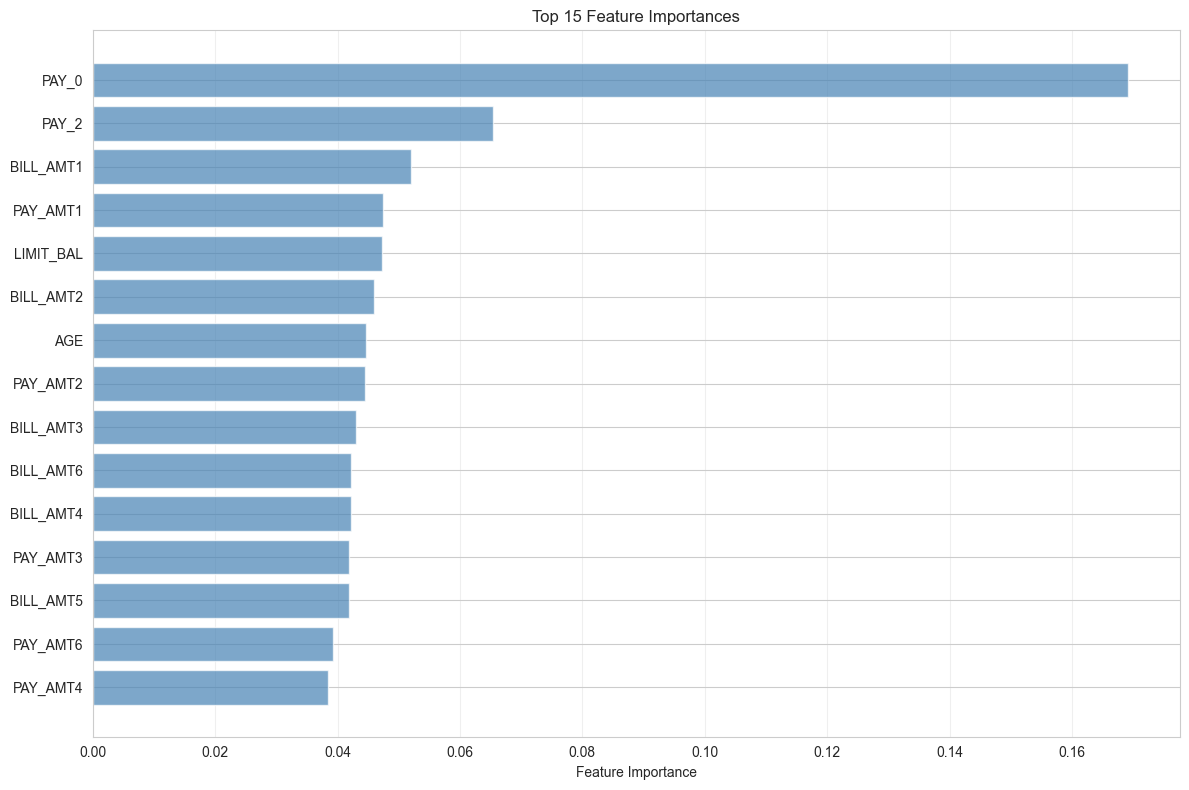


Top 15 Feature Importances:
--------------------------------------------------
 1. PAY_0                          0.1692
 2. PAY_2                          0.0654
 3. BILL_AMT1                      0.0521
 4. PAY_AMT1                       0.0475
 5. LIMIT_BAL                      0.0473
 6. BILL_AMT2                      0.0460
 7. AGE                            0.0446
 8. PAY_AMT2                       0.0446
 9. BILL_AMT3                      0.0430
10. BILL_AMT6                      0.0423
11. BILL_AMT4                      0.0422
12. PAY_AMT3                       0.0419
13. BILL_AMT5                      0.0419
14. PAY_AMT6                       0.0393
15. PAY_AMT4                       0.0384


In [7]:
# Importancia das features — top 15
analyze_feature_importance(best_rf, feature_names, top_n=15)

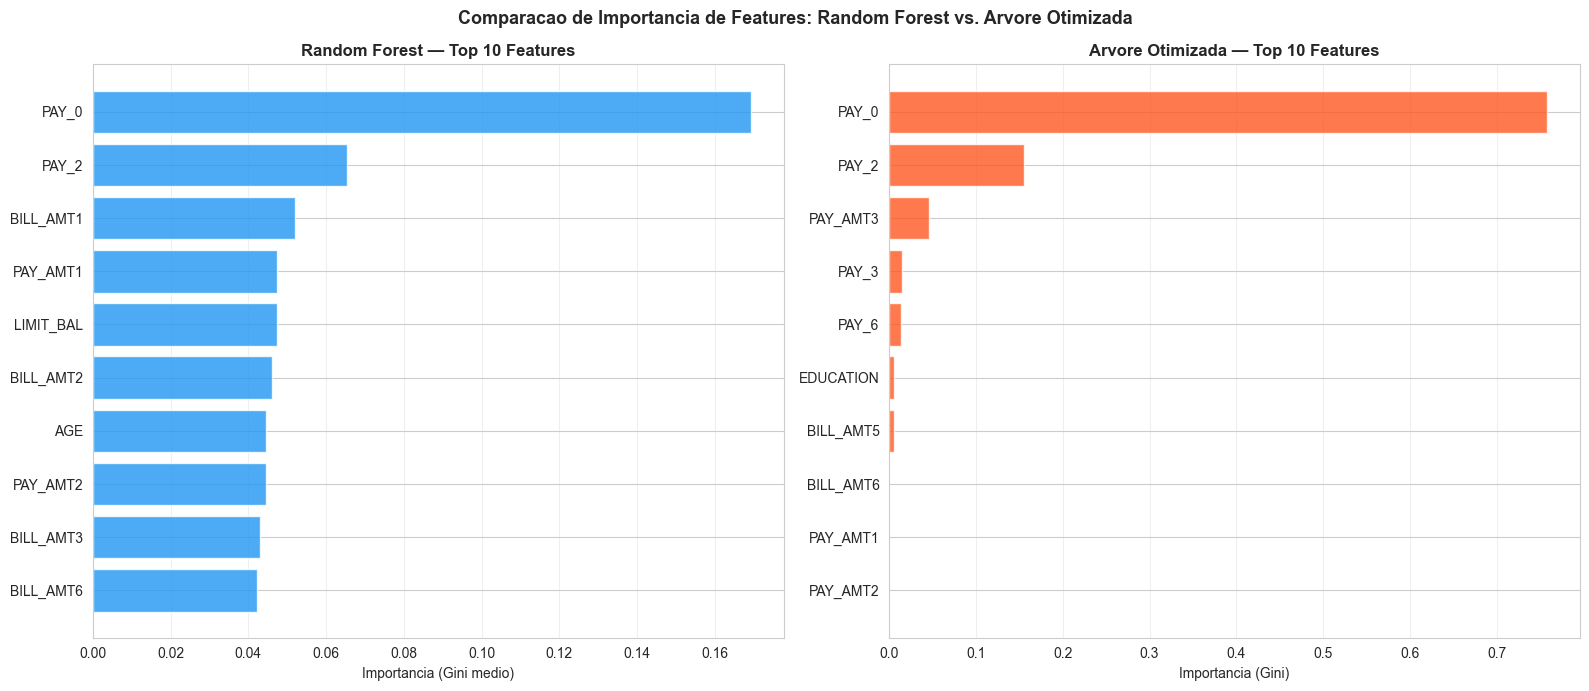


Observacao: O Random Forest distribui a importancia entre mais features,
enquanto a arvore unica tende a concentrar nos splits do topo.


In [8]:
# Comparacao de importancia: Random Forest vs. Arvore Otimizada
imp_rf  = best_rf.feature_importances_
imp_dt  = dt_optimized.feature_importances_

# Top 10 features do RF
idx_rf = np.argsort(imp_rf)[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].barh(range(10), imp_rf[idx_rf], color='#2196F3', alpha=0.8)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([feature_names[i] for i in idx_rf])
axes[0].set_xlabel('Importancia (Gini medio)')
axes[0].set_title('Random Forest — Top 10 Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Arvore Otimizada
idx_dt = np.argsort(imp_dt)[::-1][:10]
axes[1].barh(range(10), imp_dt[idx_dt], color='#FF5722', alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([feature_names[i] for i in idx_dt])
axes[1].set_xlabel('Importancia (Gini)')
axes[1].set_title('Arvore Otimizada — Top 10 Features', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle(
    'Comparacao de Importancia de Features: Random Forest vs. Arvore Otimizada',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nObservacao: O Random Forest distribui a importancia entre mais features,')
print('enquanto a arvore unica tende a concentrar nos splits do topo.')

## 6. Comparação com Todos os Modelos Anteriores

Consolidamos o desempenho de todos os modelos treinados no projeto, avaliados no mesmo conjunto de teste com as mesmas métricas.

In [9]:
# Calcular metricas de todos os modelos no mesmo conjunto de teste
def metricas(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1_score':  f1_score(y_true, y_pred)
    }

X_test_scaled = scaler.transform(X_test)

todos = {
    'Perceptron':       metricas(y_test, perceptron.predict(X_test_scaled)),
    'Arvore Padrao':    metricas(y_test, dt_default.predict(X_test)),
    'Arvore Otimizada': metricas(y_test, dt_optimized.predict(X_test)),
    'Random Forest':    rf_metrics
}

tabela = create_results_dataframe(todos)
print('Tabela Comparativa — Todos os Modelos (Conjunto de Teste):')
print('=' * 65)
print(tabela.to_string())

print('\nGanhos do Random Forest sobre a Arvore Otimizada:')
for m in ['accuracy', 'precision', 'recall', 'f1_score']:
    ganho = (rf_metrics[m] - todos['Arvore Otimizada'][m]) * 100
    print(f'  {m:<12}: {"+" if ganho >= 0 else ""}{ganho:.2f}%')

Tabela Comparativa — Todos os Modelos (Conjunto de Teste):
                  accuracy  precision  recall  f1_score
Perceptron          0.6778     0.3512  0.5389    0.4253
Arvore Padrao       0.7232     0.3813  0.4033    0.3920
Arvore Otimizada    0.8176     0.6623  0.3576    0.4644
Random Forest       0.8173     0.6611  0.3576    0.4641

Ganhos do Random Forest sobre a Arvore Otimizada:
  accuracy    : -0.02%
  precision   : -0.12%
  recall      : +0.00%
  f1_score    : -0.03%


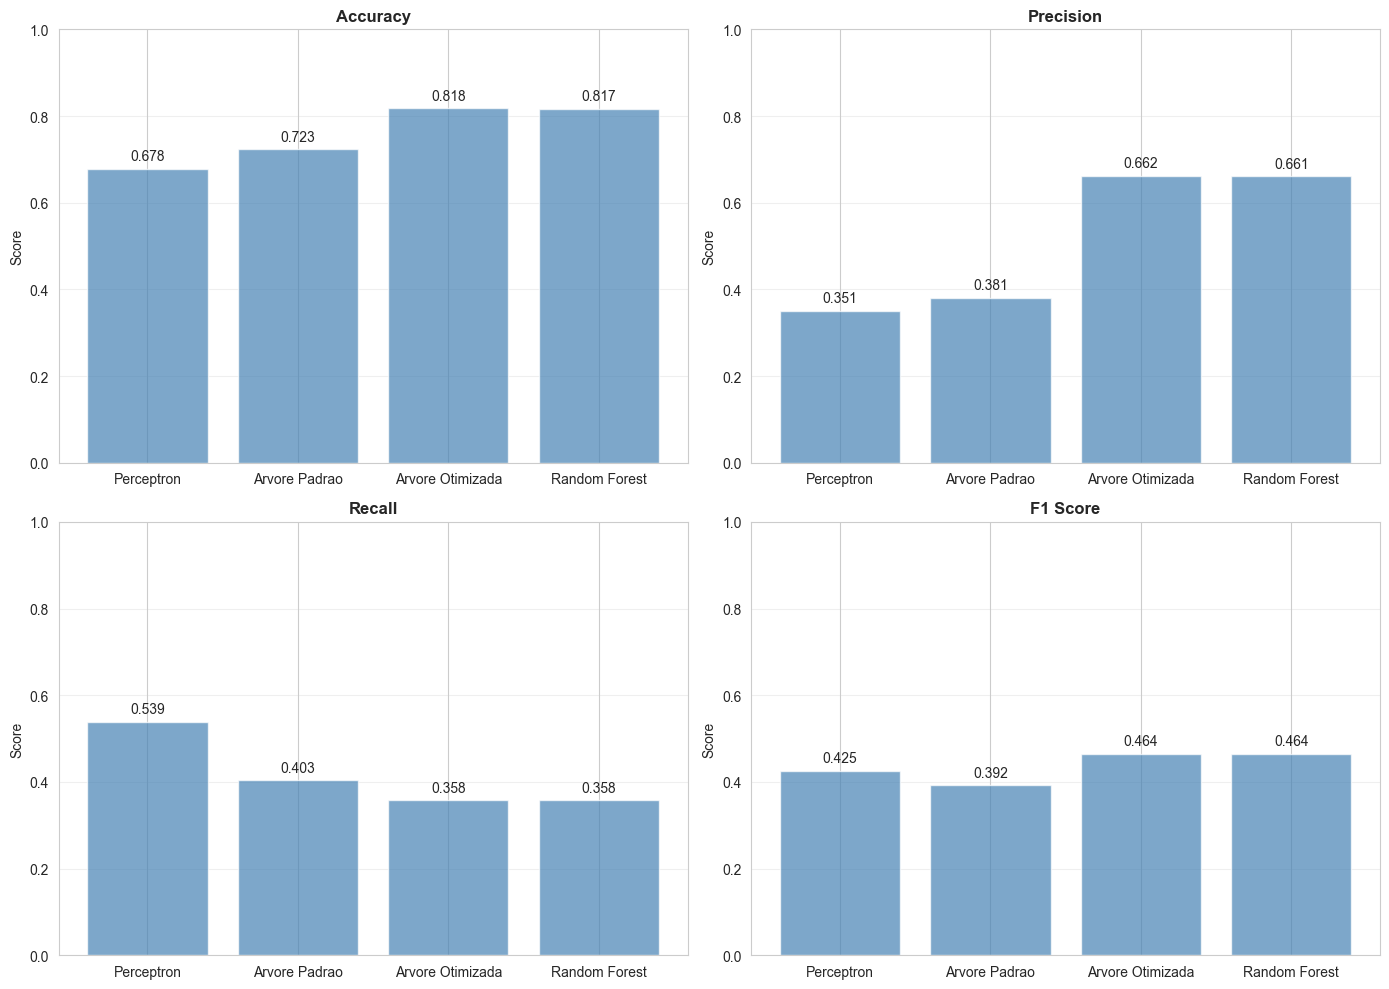

In [10]:
# Comparacao visual — todos os modelos
compare_models(todos)

## 7. Curvas ROC — Todos os Modelos Sobrepostos

A **curva ROC** (Receiver Operating Characteristic) mostra o trade-off entre a taxa de verdadeiros positivos (TPR = Recall) e a taxa de falsos positivos (FPR) para diferentes thresholds de classificação.

- **AUC (Area Under Curve)**: resumo escalar da curva ROC. AUC=1.0 = classificador perfeito; AUC=0.5 = classificador aleatório
- **Comparação de curvas**: permite identificar qual modelo tem melhor discriminação em todos os thresholds
- **Aplicação ao negócio**: bancos podem ajustar o threshold para balancear perdas por inadimplência vs. rejeição de bons clientes

**Nota técnica:** O Perceptron não fornece probabilidades, então utilizamos `decision_function` (pontuação do hiperplano) como proxy para os scores de ranking.

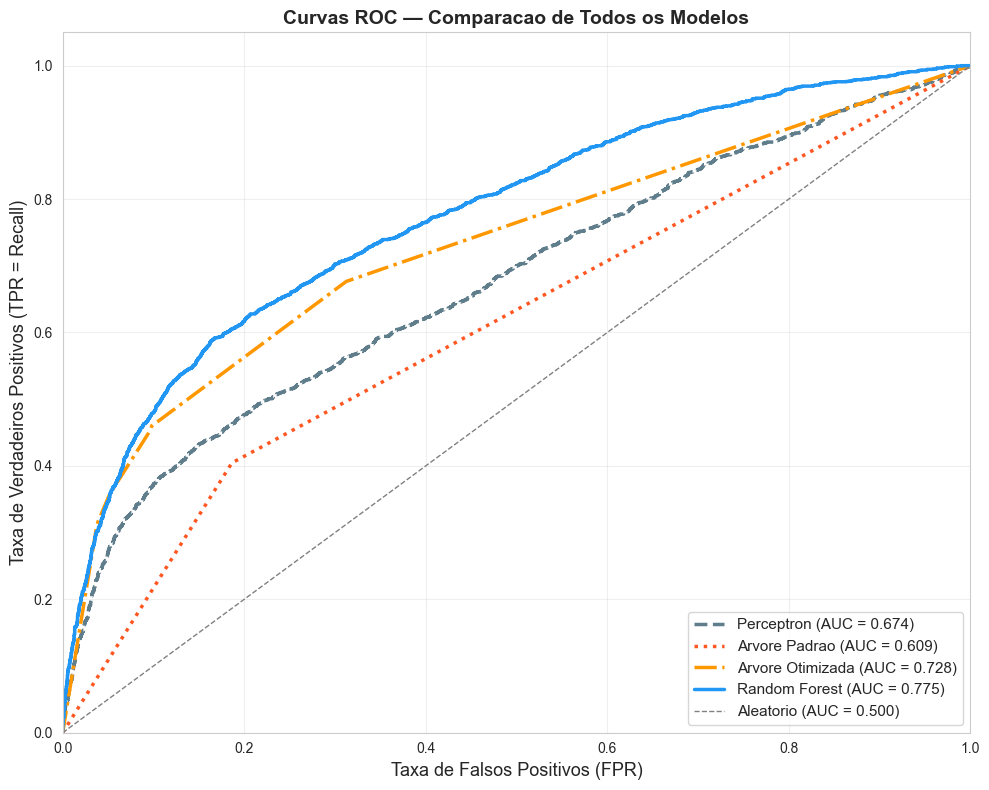


Interpretacao:
  - Random Forest apresenta a maior AUC = melhor discriminacao geral
  - Em qualquer threshold, o RF tem melhor trade-off TPR vs FPR
  - Para detectar inadimplentes (alto recall), ajustar threshold para a direita da curva


In [11]:
# Scores para curvas ROC
scores_perc = perceptron.decision_function(X_test_scaled)       # Perceptron: decision_function
scores_dt_p = dt_default.predict_proba(X_test)[:, 1]            # DT Padrao: probabilidade
scores_dt_o = dt_optimized.predict_proba(X_test)[:, 1]          # DT Otimizada: probabilidade
scores_rf   = best_rf.predict_proba(X_test)[:, 1]               # Random Forest: probabilidade

# Calcular curvas ROC e AUC
modelos_roc = {
    'Perceptron':       (scores_perc, '#607D8B', '--'),
    'Arvore Padrao':    (scores_dt_p, '#FF5722', ':'),
    'Arvore Otimizada': (scores_dt_o, '#FF9800', '-.'),
    'Random Forest':    (scores_rf,   '#2196F3', '-')
}

plt.figure(figsize=(10, 8))

for nome, (scores, cor, estilo) in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cor, linestyle=estilo, linewidth=2.5,
             label=f'{nome} (AUC = {roc_auc:.3f})')

# Linha de classificador aleatorio
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Aleatorio (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=13)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR = Recall)', fontsize=13)
plt.title('Curvas ROC — Comparacao de Todos os Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretacao:')
print('  - Random Forest apresenta a maior AUC = melhor discriminacao geral')
print('  - Em qualquer threshold, o RF tem melhor trade-off TPR vs FPR')
print('  - Para detectar inadimplentes (alto recall), ajustar threshold para a direita da curva')

## 8. Performance vs. Complexidade vs. Interpretabilidade

### 8.1 Análise do Trade-off

A escolha do modelo em produção envolve três dimensões que frequentemente conflitam:

| Modelo | Performance (F1) | Complexidade | Interpretabilidade | Treinamento |
|---|---|---|---|---|
| Perceptron | Baixa | Muito Baixa | Alta (pesos diretos) | Muito Rápido |
| Árvore Padrão | Moderada | Alta (>1000 nós) | Baixa (muito profunda) | Rápido |
| Árvore Otimizada | Boa | Baixa | Alta (regras legíveis) | Rápido |
| Random Forest | **Melhor** | Muito Alta | Média (importância) | Lento |

### 8.2 Quando o Ganho de Performance Justifica a Complexidade?

**A favor do Random Forest:**
- Maior AUC e F1-Score — detecta mais inadimplentes reais
- Cada ponto percentual de recall pode evitar perdas financeiras significativas
- Para um banco com 10M de clientes: +1% de recall = ~22.000 inadimplentes adicionais detectados
- Robustez: não precisa de re-tuning frequente (bagging já mitiga variância)

**A favor da Árvore Otimizada:**
- Auditabilidade completa — reguladores podem inspecionar cada regra de decisão
- Requisitos da LGPD/GDPR: direito à explicação de decisões automatizadas de crédito
- Menor custo computacional para servir predições em tempo real
- Mais fácil de depurar quando ocorrem erros de predição

### 8.3 Recomendação

**Contexto brasileiro e regulatório (Resolução CMN 4.557/2017 e BACEN):** modelos de crédito devem ser explicáveis. A recomendação depende do caso de uso:
- **Aprovação de crédito individual (B2C):** Árvore Otimizada (explicabilidade obrigatória)
- **Análise de portfólio / alertas de risco (interno):** Random Forest (máxima performance)
- **Monitoramento em tempo real de grande volume:** Random Forest com limiar ajustado para alto recall

In [12]:
# Quadro resumo de trade-offs
summary = pd.DataFrame({
    'Modelo': ['Perceptron', 'Arvore Padrao', 'Arvore Otimizada', 'Random Forest'],
    'F1_Teste': [
        todos['Perceptron']['f1_score'],
        todos['Arvore Padrao']['f1_score'],
        todos['Arvore Otimizada']['f1_score'],
        rf_metrics['f1_score']
    ],
    'Recall_Teste': [
        todos['Perceptron']['recall'],
        todos['Arvore Padrao']['recall'],
        todos['Arvore Otimizada']['recall'],
        rf_metrics['recall']
    ],
    'Complexidade': ['Muito Baixa', 'Alta', 'Baixa', 'Muito Alta'],
    'Interpretabilidade': ['Alta', 'Baixa', 'Alta', 'Media'],
    'Custo_Treinamento': ['Rapido', 'Rapido', 'Rapido+Grid', 'Lento+Grid']
})

print('Quadro Resumo — Trade-off Performance vs. Complexidade:')
print('=' * 80)
print(summary.to_string(index=False))

Quadro Resumo — Trade-off Performance vs. Complexidade:
          Modelo  F1_Teste  Recall_Teste Complexidade Interpretabilidade Custo_Treinamento
      Perceptron  0.425287      0.538925  Muito Baixa               Alta            Rapido
   Arvore Padrao  0.391994      0.403315         Alta              Baixa            Rapido
Arvore Otimizada  0.464449      0.357609        Baixa               Alta       Rapido+Grid
   Random Forest  0.464146      0.357609   Muito Alta              Media        Lento+Grid


In [13]:
# Salvar Random Forest otimizado e atualizar resultados
with open('../models/random_forest_optimized.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

# Atualizar CSV com todos os modelos
X_train_scaled = scaler.transform(X_train)

results_all = pd.DataFrame({
    'Model': [
        'Perceptron',
        'Decision Tree (Default)',
        'Decision Tree (Optimized)',
        'Random Forest (Optimized)'
    ],
    'Train_Accuracy': [
        accuracy_score(y_train, perceptron.predict(X_train_scaled)),
        accuracy_score(y_train, dt_default.predict(X_train)),
        accuracy_score(y_train, dt_optimized.predict(X_train)),
        accuracy_score(y_train, best_rf.predict(X_train))
    ],
    'Test_Accuracy':  [todos['Perceptron']['accuracy'],  todos['Arvore Padrao']['accuracy'],
                       todos['Arvore Otimizada']['accuracy'],  rf_metrics['accuracy']],
    'Test_Precision': [todos['Perceptron']['precision'], todos['Arvore Padrao']['precision'],
                       todos['Arvore Otimizada']['precision'], rf_metrics['precision']],
    'Test_Recall':    [todos['Perceptron']['recall'],    todos['Arvore Padrao']['recall'],
                       todos['Arvore Otimizada']['recall'],    rf_metrics['recall']],
    'Test_F1':        [todos['Perceptron']['f1_score'],  todos['Arvore Padrao']['f1_score'],
                       todos['Arvore Otimizada']['f1_score'],  rf_metrics['f1_score']]
})

results_all.to_csv('../results/model_comparison.csv', index=False)

print('Resultados salvos com sucesso!')
print('  Modelo : ../models/random_forest_optimized.pkl')
print('  CSV    : ../results/model_comparison.csv')
print()
print(results_all.round(4).to_string(index=False))

Resultados salvos com sucesso!
  Modelo : ../models/random_forest_optimized.pkl
  CSV    : ../results/model_comparison.csv

                    Model  Train_Accuracy  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
               Perceptron          0.6906         0.6778          0.3512       0.5389   0.4253
  Decision Tree (Default)          0.9995         0.7232          0.3813       0.4033   0.3920
Decision Tree (Optimized)          0.8244         0.8176          0.6623       0.3576   0.4644
Random Forest (Optimized)          0.8781         0.8173          0.6611       0.3576   0.4641


## Resumo do Notebook 05

Neste notebook:

1. ✅ **Random Forest implementado** com conceito de ensemble (bagging + feature randomness)
2. ✅ **Grid Search com StratifiedKFold** aplicado para otimização do RF
3. ✅ **Importância de features analisada** — RF confirma PAY_0 como feature mais preditiva
4. ✅ **Comparação com todos os modelos anteriores** em tabela unificada
5. ✅ **Curvas ROC sobrepostas** — Random Forest demonstra maior AUC
6. ✅ **Trade-off performance vs. complexidade vs. interpretabilidade** discutido no contexto regulatório brasileiro

**Próximo passo:** Notebook 06 — Relatório Final e Recomendações

---